In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

In [4]:
#load tile from DR2
tiles = Table.read("/global/cfs/cdirs/desi/spectro/redux/loa/tiles-loa.fits")

In [5]:
tiles

TILEID,SURVEY,PROGRAM,FAPRGRM,FAFLAVOR,NEXP,EXPTIME,TILERA,TILEDEC,EFFTIME_ETC,EFFTIME_SPEC,EFFTIME_GFA,GOALTIME,OBSSTATUS,LRG_EFFTIME_DARK,ELG_EFFTIME_DARK,BGS_EFFTIME_BRIGHT,LYA_EFFTIME_DARK,GOALTYPE,MINTFRAC,LASTNIGHT,UPDATED
int32,bytes20,bytes6,bytes20,bytes20,int64,float64,float64,float64,float64,float64,float64,float64,bytes20,float64,float64,float64,float64,bytes20,float64,int32,bytes24
80615,cmx,other,m33,cmxm33,4,3600.1,24.027,31.39,0.0,3325.2,3084.8,1000.0,obsend,3230.5,3325.2,3224.3,3594.6,other,0.9,20201216,2024-11-04T09:47:29-0800
80609,sv1,dark,lrgqso,cmxlrgqso,15,13500.7,150.12,2.206,0.0,7827.0,8106.4,4000.0,obsend,7718.3,7827.0,8039.3,10784.3,dark,0.9,20201217,2024-11-04T09:47:29-0800
80606,sv1,dark,elg,cmxelg,12,10800.7,36.448,-4.501,0.0,6723.4,6946.2,4000.0,obsend,6465.1,6723.4,6570.0,7325.5,dark,0.9,20201219,2024-11-04T09:47:29-0800
80607,sv1,dark,lrgqso,cmxlrgqso,15,13500.8,106.74,56.1,0.0,9338.7,8932.3,4000.0,obsend,8620.9,9338.7,8477.8,8179.9,dark,0.9,20201219,2024-11-04T09:47:29-0800
80622,sv1,dark,lrgqso,sv1lrgqso,6,5400.3,155.0,32.325,0.0,4950.0,5133.0,4000.0,obsend,4722.4,4950.0,4751.0,7025.4,dark,0.9,20201221,2024-11-04T09:47:29-0800
80620,sv1,dark,lrgqso,sv1lrgqso,9,8100.5,144.0,65.0,0.0,7090.0,7469.9,4000.0,obsend,6499.9,7090.0,6231.3,5972.0,dark,0.9,20201221,2024-11-04T09:47:29-0800
80623,sv1,dark,elg,sv1elg,8,7200.4,155.0,32.425,0.0,5000.9,5298.0,4000.0,obsend,4846.1,5000.9,4919.7,7301.3,dark,0.9,20201221,2024-11-04T09:47:29-0800
80611,sv1,bright,bgsmws,sv1bgsmws,12,3600.9,35.22,30.3,0.0,663.7,686.9,600.0,obsend,627.8,720.3,663.7,387.8,bright,0.9,20201222,2024-11-04T09:47:29-0800
80612,sv1,bright,bgsmws,sv1bgsmws,17,5101.3,66.68,-5.24,0.0,1455.2,1462.3,600.0,obsend,1395.4,1538.0,1455.2,786.7,bright,0.9,20201223,2024-11-04T09:47:29-0800


Total main/dark tiles: 6671

EFFTIME_SPEC statistics:
  Mean:   1030.8
  Median: 1008.9
  Std:    110.2
  Range:  [825.0, 2137.3]

EXPTIME statistics:
  Mean:   1401.3
  Median: 1211.7
  Std:    626.0
  Range:  [568.7, 5407.2]


Typical tiles (within 0.5 std of median for both):
Found 2030 typical tiles

Top 10 most typical tiles:
TILEID   EXPTIME    EFFTIME_SPEC NEXP  
----------------------------------------
7441     1217.9     1010.2       1     
1008     1221.5     1009.4       1     
8799     1214.0     1010.7       1     
3256     1204.6     1007.1       1     
5943     1197.3     1008.5       1     
8411     1225.3     1010.3       2     
3550     1213.3     1012.0       1     
8938     1229.0     1007.8       1     
2963     1207.2     1005.5       1     
4401     1190.8     1007.4       1     

Plot saved to tiles_analysis.png
Saved top 20 typical tiles to typical_tiles.fits


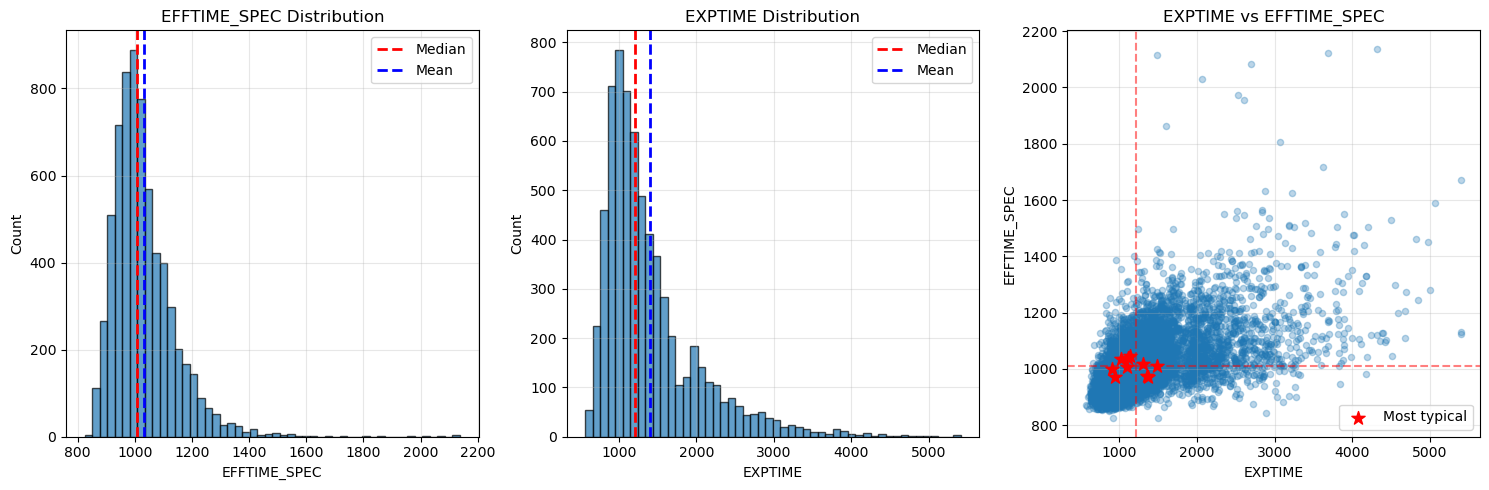

In [7]:
# Filter for main survey dark tiles
main_dark = tiles[(tiles['SURVEY'] == 'main') & (tiles['PROGRAM'] == 'dark')]

print(f"Total main/dark tiles: {len(main_dark)}")
print("\n" + "="*60)

# Calculate statistics for EFFTIME_SPEC
efftime_spec = main_dark['EFFTIME_SPEC']
efftime_mean = np.mean(efftime_spec)
efftime_median = np.median(efftime_spec)
efftime_std = np.std(efftime_spec)

print("EFFTIME_SPEC statistics:")
print(f"  Mean:   {efftime_mean:.1f}")
print(f"  Median: {efftime_median:.1f}")
print(f"  Std:    {efftime_std:.1f}")
print(f"  Range:  [{np.min(efftime_spec):.1f}, {np.max(efftime_spec):.1f}]")

# Calculate statistics for EXPTIME
exptime = main_dark['EXPTIME']
exptime_mean = np.mean(exptime)
exptime_median = np.median(exptime)
exptime_std = np.std(exptime)

print("\nEXPTIME statistics:")
print(f"  Mean:   {exptime_mean:.1f}")
print(f"  Median: {exptime_median:.1f}")
print(f"  Std:    {exptime_std:.1f}")
print(f"  Range:  [{np.min(exptime):.1f}, {np.max(exptime):.1f}]")

print("\n" + "="*60)

# Find tiles close to median values
# We'll look for tiles within 0.5 std of the median for both parameters
efftime_typical = (efftime_spec > efftime_median - 0.5*efftime_std) & \
                  (efftime_spec < efftime_median + 0.5*efftime_std)
exptime_typical = (exptime > exptime_median - 0.5*exptime_std) & \
                  (exptime < exptime_median + 0.5*exptime_std)

typical_tiles = main_dark[efftime_typical & exptime_typical]

print(f"\nTypical tiles (within 0.5 std of median for both):")
print(f"Found {len(typical_tiles)} typical tiles\n")

# Show top 10 most typical tiles (closest to median)
if len(typical_tiles) > 0:
    # Calculate distance from median for both parameters (normalized)
    efftime_dist = np.abs(typical_tiles['EFFTIME_SPEC'] - efftime_median) / efftime_std
    exptime_dist = np.abs(typical_tiles['EXPTIME'] - exptime_median) / exptime_std
    combined_dist = np.sqrt(efftime_dist**2 + exptime_dist**2)
    
    # Sort by combined distance
    idx_sorted = np.argsort(combined_dist)
    
    print("Top 10 most typical tiles:")
    print(f"{'TILEID':<8} {'EXPTIME':<10} {'EFFTIME_SPEC':<12} {'NEXP':<6}")
    print("-" * 40)
    for i in idx_sorted[:10]:
        t = typical_tiles[i]
        print(f"{t['TILEID']:<8} {t['EXPTIME']:<10.1f} {t['EFFTIME_SPEC']:<12.1f} {t['NEXP']:<6}")

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: EFFTIME_SPEC histogram
axes[0].hist(efftime_spec, bins=50, alpha=0.7, edgecolor='black')
axes[0].axvline(efftime_median, color='red', linestyle='--', linewidth=2, label='Median')
axes[0].axvline(efftime_mean, color='blue', linestyle='--', linewidth=2, label='Mean')
axes[0].set_xlabel('EFFTIME_SPEC')
axes[0].set_ylabel('Count')
axes[0].set_title('EFFTIME_SPEC Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: EXPTIME histogram
axes[1].hist(exptime, bins=50, alpha=0.7, edgecolor='black')
axes[1].axvline(exptime_median, color='red', linestyle='--', linewidth=2, label='Median')
axes[1].axvline(exptime_mean, color='blue', linestyle='--', linewidth=2, label='Mean')
axes[1].set_xlabel('EXPTIME')
axes[1].set_ylabel('Count')
axes[1].set_title('EXPTIME Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Scatter plot
axes[2].scatter(exptime, efftime_spec, alpha=0.3, s=20)
if len(typical_tiles) > 0:
    axes[2].scatter(typical_tiles['EXPTIME'][:10], typical_tiles['EFFTIME_SPEC'][:10], 
                   color='red', s=100, marker='*', label='Most typical', zorder=5)
axes[2].axhline(efftime_median, color='red', linestyle='--', alpha=0.5)
axes[2].axvline(exptime_median, color='red', linestyle='--', alpha=0.5)
axes[2].set_xlabel('EXPTIME')
axes[2].set_ylabel('EFFTIME_SPEC')
axes[2].set_title('EXPTIME vs EFFTIME_SPEC')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tiles_analysis.png', dpi=150, bbox_inches='tight')
print(f"\nPlot saved to tiles_analysis.png")

# Save a list of recommended tiles
if len(typical_tiles) > 0:
    recommended = typical_tiles[idx_sorted[:20]]
    recommended.write('typical_tiles.fits', overwrite=True)
    print(f"Saved top 20 typical tiles to typical_tiles.fits")